In [6]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/ngeikerry/football/results.csv")
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [7]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ngeikerry/football/former_names.csv
/kaggle/input/datasets/ngeikerry/football/goalscorers.csv
/kaggle/input/datasets/ngeikerry/football/shootouts.csv
/kaggle/input/datasets/ngeikerry/football/results.csv


In [8]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/ngeikerry/football/results.csv")
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [9]:
# How many matches are in the dataset?
print("Total matches:", df.shape[0])

# Earliest and latest year
df["date"] = pd.to_datetime(df["date"])
print("Earliest match:", df["date"].min().year)
print("Latest match:", df["date"].max().year)

# How many unique countries?
all_teams = pd.concat([df["home_team"], df["away_team"]])
print("Unique countries:", all_teams.nunique())

# Which team appears most as home team?
print("Most frequent home team:")
print(df["home_team"].value_counts().head(1))

Total matches: 49287
Earliest match: 1872
Latest match: 2026
Unique countries: 333
Most frequent home team:
home_team
Brazil    614
Name: count, dtype: int64


In [10]:
# Create total goals column
df["total_goals"] = df["home_score"] + df["away_score"]

# Average goals per match
print("Avg goals per match:", round(df["total_goals"].mean(), 2))

# Highest scoring match
highest = df.loc[df["total_goals"].idxmax()]
print("\nHighest scoring match:")
print(highest[["date", "home_team", "away_team", "home_score", "away_score", "total_goals"]])

# Home vs Away goals
print("\nTotal home goals:", df["home_score"].sum())
print("Total away goals:", df["away_score"].sum())

# Most common total goals value
print("\nMost common total goals:", df["total_goals"].mode()[0])

Avg goals per match: 2.94

Highest scoring match:
date           2001-04-11 00:00:00
home_team                Australia
away_team           American Samoa
home_score                    31.0
away_score                     0.0
total_goals                   31.0
Name: 25420, dtype: object

Total home goals: 86426.0
Total away goals: 58192.0

Most common total goals: 2.0


In [11]:
# Create result column
def match_result(row):
    if row["home_score"] > row["away_score"]:
        return "Home Win"
    elif row["home_score"] < row["away_score"]:
        return "Away Win"
    else:
        return "Draw"

df["result"] = df.apply(match_result, axis=1)

# Percentage of each result
result_pct = df["result"].value_counts(normalize=True) * 100
print("Match result percentages:")
print(result_pct.round(2))

# Which country has the most wins?
home_wins = df[df["result"] == "Home Win"]["home_team"].value_counts()
away_wins = df[df["result"] == "Away Win"]["away_team"].value_counts()
total_wins = home_wins.add(away_wins, fill_value=0).sort_values(ascending=False)
print("\nCountry with most wins:")
print(total_wins.head(1))

Match result percentages:
result
Home Win    48.91
Away Win    28.23
Draw        22.86
Name: proportion, dtype: float64

Country with most wins:
Brazil    670.0
Name: count, dtype: float64


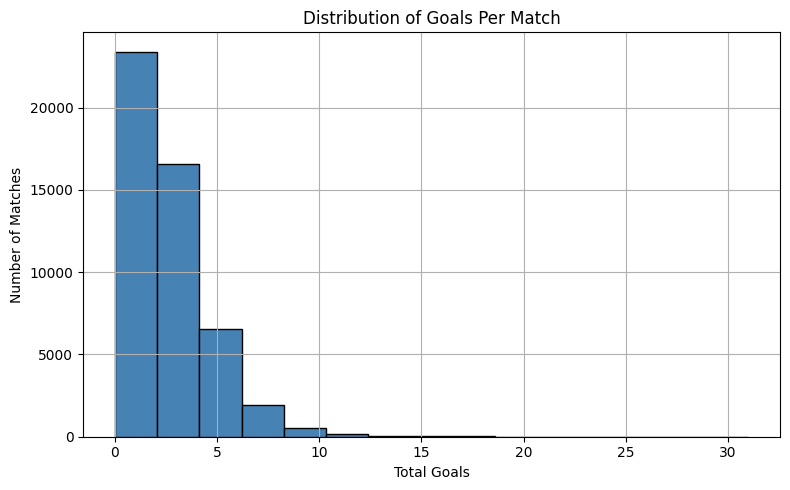

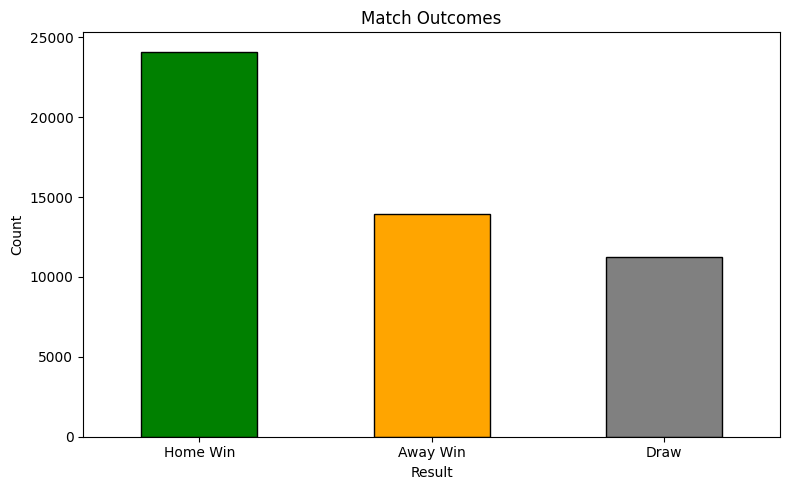

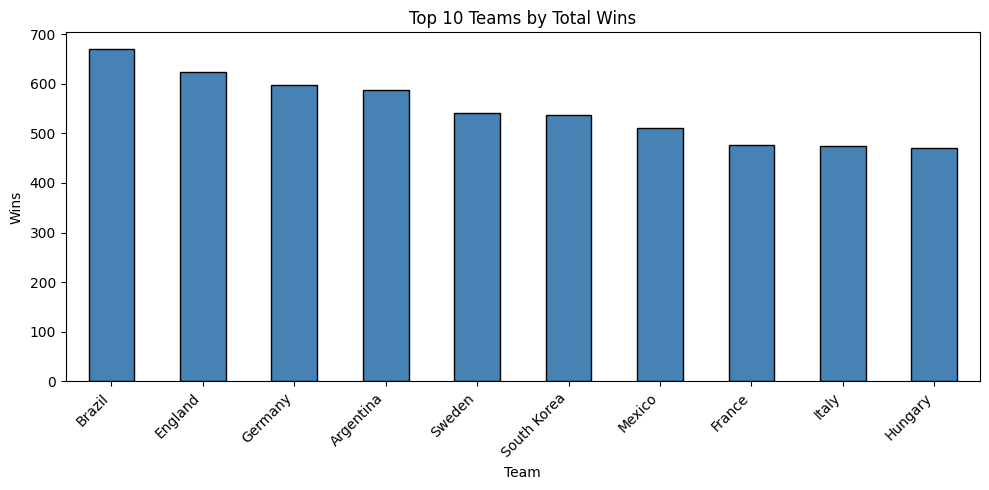

In [12]:
import matplotlib.pyplot as plt

# 1. Histogram of goals per match
plt.figure(figsize=(8,5))
df["total_goals"].hist(bins=15, color="steelblue", edgecolor="black")
plt.title("Distribution of Goals Per Match")
plt.xlabel("Total Goals")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

# 2. Bar chart of match outcomes
plt.figure(figsize=(8,5))
df["result"].value_counts().plot(kind="bar", color=["green","orange","gray"], edgecolor="black")
plt.title("Match Outcomes")
plt.xlabel("Result")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Top 10 teams by total wins
plt.figure(figsize=(10,5))
total_wins.head(10).plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Top 10 Teams by Total Wins")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()